In [13]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import beta
from IPython.display import clear_output

In [14]:
np.random.seed(123)

theta_real = 0.63

n_obs = 100

alpha = 1
beta_par = 1

hist_alpha = []
hist_beta = []

In [15]:
for k in range(n_obs):

    x = np.random.rand()

    if x < theta_real:
        alpha += 1
        lado = "L"
    else:
        beta_par += 1
        lado = "R"

    hist_alpha.append(alpha)
    hist_beta.append(beta_par)

In [16]:
theta_grid = np.linspace(0,1,1000)

alpha = 1
beta_par = 1

monedas = []

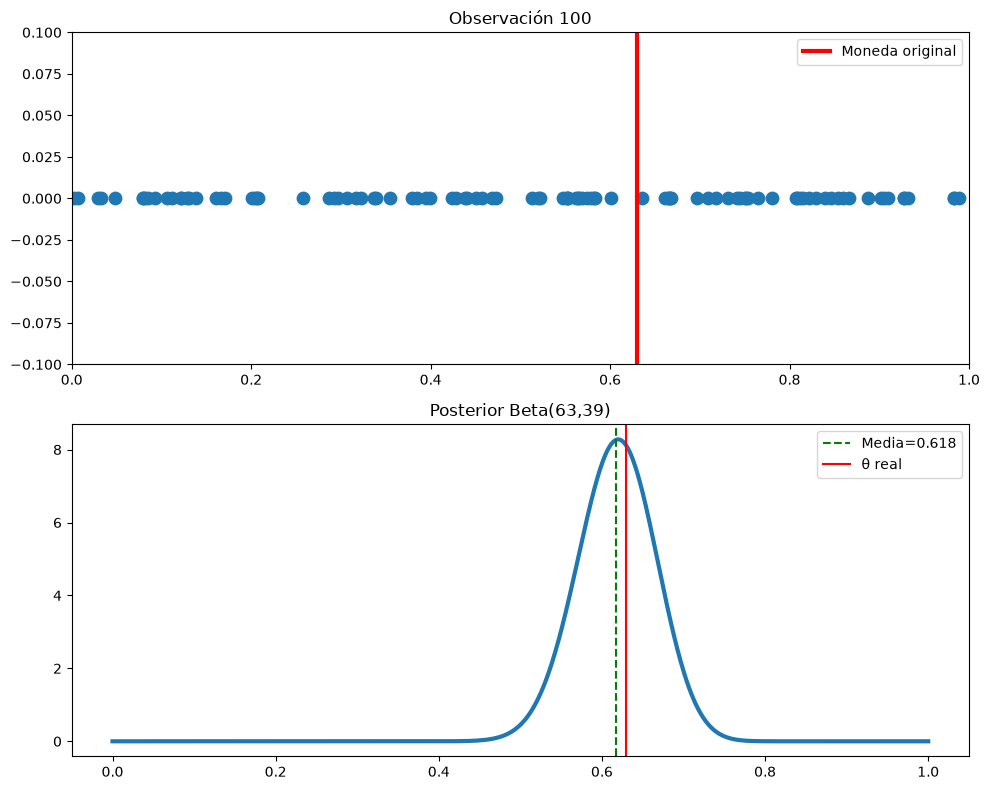

In [17]:
for k in range(n_obs):

    x = np.random.rand()

    monedas.append(x)

    if x < theta_real:
        alpha += 1
    else:
        beta_par += 1

    clear_output(wait=True)

    fig,ax = plt.subplots(
        2,1,
        figsize=(10,8)
    )

    # -------------------------
    # Mesa
    # -------------------------

    ax[0].axvline(
        theta_real,
        color="red",
        linewidth=3,
        label="Moneda original"
    )

    ax[0].scatter(
        monedas,
        np.zeros(len(monedas)),
        s=80
    )

    ax[0].set_xlim(0,1)
    ax[0].set_ylim(-0.1,0.1)
    ax[0].set_title(
        f"Observación {k+1}"
    )

    ax[0].legend()

    # -------------------------
    # Posterior
    # -------------------------

    pdf = beta.pdf(
        theta_grid,
        alpha,
        beta_par
    )

    ax[1].plot(
        theta_grid,
        pdf,
        linewidth=3
    )

    media = alpha/(alpha+beta_par)

    ax[1].axvline(
        media,
        color="green",
        linestyle="--",
        label=f"Media={media:.3f}"
    )

    ax[1].axvline(
        theta_real,
        color="red",
        label="θ real"
    )

    ax[1].set_title(
        rf"Posterior Beta({alpha},{beta_par})"
    )

    ax[1].legend()

    plt.tight_layout()
    plt.show()

    plt.pause(0.001)